**Module** is an abstract class which defines fundamental methods necessary for a training a neural network. You do not need to change anything here, just read the comments.

In [1]:
import numpy as np

In [2]:
class Module(object):
    """
    Basically, you can think of a module as of a something (black box)
    which can process `input` data and produce `ouput` data.
    This is like applying a function which is called `forward`:

        output = module.forward(input)

    The module should be able to perform a backward pass: to differentiate the `forward` function.
    More, it should be able to differentiate it if is a part of chain (chain rule).
    The latter implies there is a gradient from previous step of a chain rule.

        gradInput = module.backward(input, gradOutput)
    """
    def __init__ (self):
        self.output = None
        self.gradInput = None
        self.training = True

    def forward(self, input):
        """
        Takes an input object, and computes the corresponding output of the module.
        """
        return self.updateOutput(input)

    def backward(self,input, gradOutput):
        """
        Performs a backpropagation step through the module, with respect to the given input.

        This includes
         - computing a gradient w.r.t. `input` (is needed for further backprop),
         - computing a gradient w.r.t. parameters (to update parameters while optimizing).
        """
        self.updateGradInput(input, gradOutput)
        self.accGradParameters(input, gradOutput)
        return self.gradInput


    def updateOutput(self, input):
        """
        Computes the output using the current parameter set of the class and input.
        This function returns the result which is stored in the `output` field.

        Make sure to both store the data in `output` field and return it.
        """

        # The easiest case:

        # self.output = input
        # return self.output

        pass

    def updateGradInput(self, input, gradOutput):
        """
        Computing the gradient of the module with respect to its own input.
        This is returned in `gradInput`. Also, the `gradInput` state variable is updated accordingly.

        The shape of `gradInput` is always the same as the shape of `input`.

        Make sure to both store the gradients in `gradInput` field and return it.
        """

        # The easiest case:

        # self.gradInput = gradOutput
        # return self.gradInput

        pass

    def accGradParameters(self, input, gradOutput):
        """
        Computing the gradient of the module with respect to its own parameters.
        No need to override if module has no parameters (e.g. ReLU).
        """
        pass

    def zeroGradParameters(self):
        """
        Zeroes `gradParams` variable if the module has params.
        """
        pass

    def getParameters(self):
        """
        Returns a list with its parameters.
        If the module does not have parameters return empty list.
        """
        return []

    def getGradParameters(self):
        """
        Returns a list with gradients with respect to its parameters.
        If the module does not have parameters return empty list.
        """
        return []

    def train(self):
        """
        Sets training mode for the module.
        Training and testing behaviour differs for Dropout, BatchNorm.
        """
        self.training = True

    def evaluate(self):
        """
        Sets evaluation mode for the module.
        Training and testing behaviour differs for Dropout, BatchNorm.
        """
        self.training = False

    def __repr__(self):
        """
        Pretty printing. Should be overrided in every module if you want
        to have readable description.
        """
        return "Module"

# Sequential container

**Define** a forward and backward pass procedures.

In [3]:
class Sequential(Module):
    def __init__ (self):
        super(Sequential, self).__init__()
        self.modules = []

    def add(self, module):
        self.modules.append(module)

    def updateOutput(self, input):
        self.forward_inputs = [input]
        x = input

        for module in self.modules:
            x = module.forward(x)
            self.forward_inputs.append(x)

        self.output = x
        return self.output

    def backward(self, input, gradOutput):
        grad = gradOutput

        for i in range(len(self.modules) - 1, -1, -1):
            module = self.modules[i]
            layer_input = self.forward_inputs[i]
            grad = module.backward(layer_input, grad)

        self.gradInput = grad
        return self.gradInput

    def zeroGradParameters(self):
        for module in self.modules:
            module.zeroGradParameters()

    def getParameters(self):
        return [x.getParameters() for x in self.modules]

    def getGradParameters(self):
        return [x.getGradParameters() for x in self.modules]

    def __repr__(self):
        string = "".join([str(x) + '\n' for x in self.modules])
        return string

    def __getitem__(self, x):
        return self.modules.__getitem__(x)

    def train(self):
        self.training = True
        for module in self.modules:
            module.train()

    def evaluate(self):
        self.training = False
        for module in self.modules:
            module.evaluate()

# Layers

## 1 (0.2). Linear transform layer
Also known as dense layer, fully-connected layer, FC-layer, InnerProductLayer (in caffe), affine transform
- input:   **`batch_size x n_feats1`**
- output: **`batch_size x n_feats2`**

In [4]:
class Linear(Module):
    """
    A module which applies a linear transformation
    A common name is fully-connected layer, InnerProductLayer in caffe.

    The module should work with 2D input of shape (n_samples, n_feature).
    """
    def __init__(self, n_in, n_out):
        super(Linear, self).__init__()

        # This is a nice initialization
        stdv = 1./np.sqrt(n_in)
        self.W = np.random.uniform(-stdv, stdv, size = (n_out, n_in))
        self.b = np.random.uniform(-stdv, stdv, size = n_out)

        self.gradW = np.zeros_like(self.W)
        self.gradb = np.zeros_like(self.b)

    def updateOutput(self, input):
        # Your code goes here. ################################################
        self.output = input @ self.W.T + self.b
        return self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        # self.gradInput = ...
        self.gradInput = gradOutput @ self.W
        return self.gradInput

    def accGradParameters(self, input, gradOutput):
        # Your code goes here. ################################################
        # self.gradW = ... ; self.gradb = ...
        self.gradW += gradOutput.T @ input
        self.gradb += gradOutput.sum(axis=0)
        pass

    def zeroGradParameters(self):
        self.gradW.fill(0)
        self.gradb.fill(0)

    def getParameters(self):
        return [self.W, self.b]

    def getGradParameters(self):
        return [self.gradW, self.gradb]

    def __repr__(self):
        s = self.W.shape
        q = 'Linear %d -> %d' %(s[1],s[0])
        return q

## 2. (0.2) SoftMax
- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

$\text{softmax}(x)_i = \frac{\exp x_i} {\sum_j \exp x_j}$

Recall that $\text{softmax}(x) == \text{softmax}(x - \text{const})$. It makes possible to avoid computing exp() from large argument.

In [5]:
class SoftMax(Module):
    def __init__(self):
         super(SoftMax, self).__init__()

    def updateOutput(self, input):
        self.output = np.subtract(input, input.max(axis=1, keepdims=True))
        exp_input = np.exp(self.output)
        self.output = exp_input / exp_input.sum(axis=1, keepdims=True)
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = self.output * (
            gradOutput - np.sum(gradOutput * self.output, axis=1, keepdims=True)
        )
        return self.gradInput

    def __repr__(self):
        return "SoftMax"

## 3. (0.2) LogSoftMax
- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

$\text{logsoftmax}(x)_i = \log\text{softmax}(x)_i = x_i - \log {\sum_j \exp x_j}$

The main goal of this layer is to be used in computation of log-likelihood loss.

In [6]:
class LogSoftMax(Module):
    def __init__(self):
         super(LogSoftMax, self).__init__()

    def updateOutput(self, input):
        shifted = input - np.max(input, axis=1, keepdims=True)
        logsumexp = np.log(np.sum(np.exp(shifted), axis=1, keepdims=True))
        self.output = shifted - logsumexp
        return self.output

    def updateGradInput(self, input, gradOutput):
        softmax = np.exp(self.output)
        self.gradInput = gradOutput - softmax * np.sum(gradOutput, axis=1, keepdims=True)
        return self.gradInput

    def __repr__(self):
        return "LogSoftMax"

## 4. (0.3) Batch normalization
One of the most significant recent ideas that impacted NNs a lot is [**Batch normalization**](http://arxiv.org/abs/1502.03167). The idea is simple, yet effective: the features should be whitened ($mean = 0$, $std = 1$) all the way through NN. This improves the convergence for deep models letting it train them for days but not weeks. **You are** to implement the first part of the layer: features normalization. The second part (`ChannelwiseScaling` layer) is implemented below.

- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

The layer should work as follows. While training (`self.training == True`) it transforms input as $$y = \frac{x - \mu}  {\sqrt{\sigma + \epsilon}}$$
where $\mu$ and $\sigma$ - mean and variance of feature values in **batch** and $\epsilon$ is just a small number for numericall stability. Also during training, layer should maintain exponential moving average values for mean and variance:
```
    self.moving_mean = self.moving_mean * alpha + batch_mean * (1 - alpha)
    self.moving_variance = self.moving_variance * alpha + batch_variance * (1 - alpha)
```
During testing (`self.training == False`) the layer normalizes input using moving_mean and moving_variance.

Note that decomposition of batch normalization on normalization itself and channelwise scaling here is just a common **implementation** choice. In general "batch normalization" always assumes normalization + scaling.

In [7]:
class BatchNormalization(Module):
    EPS = 1e-5

    def __init__(self, alpha=0.9):
        super(BatchNormalization, self).__init__()
        self.alpha = alpha

        self.moving_mean = None
        self.moving_variance = None

        self.batch_mean = None
        self.batch_variance = None
        self.centered_input = None
        self.std_inv = None

    def updateOutput(self, input):
        if self.moving_mean is None:
            self.moving_mean = np.zeros(input.shape[1], dtype=np.float32)
            self.moving_variance = np.ones(input.shape[1], dtype=np.float32)

        if self.training:
            x = torch.from_numpy(input.astype(np.float32))

            self.batch_mean = x.mean(dim=0).numpy()
            self.batch_variance = x.var(dim=0, unbiased=False).numpy()

            self.centered_input = input - self.batch_mean
            self.std_inv = 1.0 / np.sqrt(self.batch_variance + self.EPS)
            self.output = self.centered_input * self.std_inv

            # для running variance torch обновляет через unbiased variance
            batch_var_unbiased = x.var(dim=0, unbiased=True).numpy()

            self.moving_mean = (
                self.alpha * self.moving_mean + (1.0 - self.alpha) * self.batch_mean
            ).astype(np.float32)

            self.moving_variance = (
                self.alpha * self.moving_variance + (1.0 - self.alpha) * batch_var_unbiased
            ).astype(np.float32)
        else:
            self.output = (input - self.moving_mean) / np.sqrt(self.moving_variance + self.EPS)

        return self.output

    def updateGradInput(self, input, gradOutput):
        mean_grad = np.mean(gradOutput, axis=0)
        mean_grad_xhat = np.mean(gradOutput * self.output, axis=0)

        self.gradInput = (1.0 / np.sqrt(self.batch_variance + self.EPS)) * (
            gradOutput - mean_grad - self.output * mean_grad_xhat
        )

        return self.gradInput

    def __repr__(self):
        return "BatchNormalization"

In [8]:
class ChannelwiseScaling(Module):
    def __init__(self, n_out):
        super(ChannelwiseScaling, self).__init__()

        self.gamma = np.ones(n_out, dtype=np.float32)
        self.beta = np.zeros(n_out, dtype=np.float32)

        self.gradGamma = np.zeros_like(self.gamma)
        self.gradBeta = np.zeros_like(self.beta)

    def updateOutput(self, input):
        self.output = input * self.gamma[None, :] + self.beta[None, :]
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = gradOutput * self.gamma[None, :]
        return self.gradInput

    def accGradParameters(self, input, gradOutput):
        self.gradGamma = np.sum(input * gradOutput, axis=0)
        self.gradBeta = np.sum(gradOutput, axis=0)

    def zeroGradParameters(self):
        self.gradGamma.fill(0)
        self.gradBeta.fill(0)

    def getParameters(self):
        return [self.gamma, self.beta]

    def getGradParameters(self):
        return [self.gradGamma, self.gradBeta]

    def __repr__(self):
        return "ChannelwiseScaling"

Practical notes. If BatchNormalization is placed after a linear transformation layer (including dense layer, convolutions, channelwise scaling) that implements function like `y = weight * x + bias`, than bias adding become useless and could be omitted since its effect will be discarded while batch mean subtraction. If BatchNormalization (followed by `ChannelwiseScaling`) is placed before a layer that propagates scale (including ReLU, LeakyReLU) followed by any linear transformation layer than parameter `gamma` in `ChannelwiseScaling` could be freezed since it could be absorbed into the linear transformation layer.

## 5. (0.3) Dropout
Implement [**dropout**](https://www.cs.toronto.edu/~hinton/absps/JMLRdropout.pdf). The idea and implementation is really simple: just multimply the input by $Bernoulli(p)$ mask. Here $p$ is probability of an element to be zeroed.

This has proven to be an effective technique for regularization and preventing the co-adaptation of neurons.

While training (`self.training == True`) it should sample a mask on each iteration (for every batch), zero out elements and multiply elements by $1 / (1 - p)$. The latter is needed for keeping mean values of features close to mean values which will be in test mode. When testing this module should implement identity transform i.e. `self.output = input`.

- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

In [9]:
class Dropout(Module):
    def __init__(self, p=0.5):
        super(Dropout, self).__init__()

        self.p = p
        self.mask = None

    def updateOutput(self, input):
        # Your code goes here. ################################################
        if self.training:
            self.mask = (np.random.rand(*input.shape) > self.p).astype(input.dtype)
            self.output = input * self.mask / (1.0 - self.p)
        else:
            self.output = input
        return self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        if self.training:
            self.gradInput = gradOutput * self.mask / (1.0 - self.p)
        else:
            self.gradInput = gradOutput
        return self.gradInput

    def __repr__(self):
        return "Dropout"

#6. (2.0) Conv2d
Implement [**Conv2d**](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html). Use only this list of parameters: (in_channels, out_channels, kernel_size, stride, padding, bias, padding_mode) and fix dilation=1 and groups=1.

In [10]:
import numpy as np


class Conv2d(Module):
    def __init__(self, in_channels, out_channels, kernel_size,
                 stride=1, padding=0, bias=True, padding_mode='zeros'):
        super(Conv2d, self).__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size if isinstance(kernel_size, tuple) else (kernel_size, kernel_size)
        self.stride = stride if isinstance(stride, tuple) else (stride, stride)
        self.padding = padding
        self.use_bias = bias
        self.padding_mode = padding_mode

        kh, kw = self.kernel_size
        stdv = 1.0 / np.sqrt(in_channels * kh * kw)

        self.weight = np.random.uniform(
            -stdv, stdv, size=(out_channels, in_channels, kh, kw)
        ).astype(np.float32)
        self.gradWeight = np.zeros_like(self.weight)

        if self.use_bias:
            self.bias = np.random.uniform(-stdv, stdv, size=(out_channels,)).astype(np.float32)
            self.gradBias = np.zeros_like(self.bias)
        else:
            self.bias = None
            self.gradBias = None

        # алиасы, если где-то в ноуте ожидаются старые имена
        self.W = self.weight
        self.gradW = self.gradWeight
        self.b = self.bias
        self.gradb = self.gradBias

    def _get_padding(self, input_shape):
        _, _, H, W = input_shape
        kh, kw = self.kernel_size
        sh, sw = self.stride

        if self.padding == 'same':
            out_h = int(np.ceil(H / sh))
            out_w = int(np.ceil(W / sw))

            pad_h_total = max((out_h - 1) * sh + kh - H, 0)
            pad_w_total = max((out_w - 1) * sw + kw - W, 0)

            ph_top = pad_h_total // 2
            ph_bottom = pad_h_total - ph_top
            pw_left = pad_w_total // 2
            pw_right = pad_w_total - pw_left

            return ph_top, ph_bottom, pw_left, pw_right

        if isinstance(self.padding, tuple):
            ph, pw = self.padding
        else:
            ph, pw = self.padding, self.padding

        return ph, ph, pw, pw

    def _pad_input(self, input):
        ph_top, ph_bottom, pw_left, pw_right = self._get_padding(input.shape)

        if ph_top == 0 and ph_bottom == 0 and pw_left == 0 and pw_right == 0:
            return input

        if self.padding_mode == 'zeros':
            return np.pad(
                input,
                ((0, 0), (0, 0), (ph_top, ph_bottom), (pw_left, pw_right)),
                mode='constant',
                constant_values=0
            )
        elif self.padding_mode == 'replicate':
            return np.pad(
                input,
                ((0, 0), (0, 0), (ph_top, ph_bottom), (pw_left, pw_right)),
                mode='edge'
            )
        elif self.padding_mode == 'reflect':
            return np.pad(
                input,
                ((0, 0), (0, 0), (ph_top, ph_bottom), (pw_left, pw_right)),
                mode='reflect'
            )
        else:
            raise ValueError(f"Unsupported padding_mode: {self.padding_mode}")

    def _map_reflect_index(self, idx, size):
        while idx < 0 or idx >= size:
            if idx < 0:
                idx = -idx
            if idx >= size:
                idx = 2 * size - 2 - idx
        return idx

    def _unpad_grad(self, grad_padded, input):
        ph_top, ph_bottom, pw_left, pw_right = self._get_padding(input.shape)
        H, W = input.shape[2], input.shape[3]

        if self.padding_mode == 'zeros':
            return grad_padded[:, :, ph_top:ph_top + H, pw_left:pw_left + W]

        grad_input = np.zeros_like(input)
        N, C, H_p, W_p = grad_padded.shape

        for n in range(N):
            for c in range(C):
                for i in range(H_p):
                    ii = i - ph_top
                    if self.padding_mode == 'replicate':
                        ii = min(max(ii, 0), H - 1)
                    elif self.padding_mode == 'reflect':
                        ii = self._map_reflect_index(ii, H)

                    for j in range(W_p):
                        jj = j - pw_left
                        if self.padding_mode == 'replicate':
                            jj = min(max(jj, 0), W - 1)
                        elif self.padding_mode == 'reflect':
                            jj = self._map_reflect_index(jj, W)

                        grad_input[n, c, ii, jj] += grad_padded[n, c, i, j]

        return grad_input

    def updateOutput(self, input):
        batch_size, in_channels, H, W = input.shape
        kh, kw = self.kernel_size
        sh, sw = self.stride

        x_padded = self._pad_input(input)
        H_p, W_p = x_padded.shape[2], x_padded.shape[3]

        H_out = (H_p - kh) // sh + 1
        W_out = (W_p - kw) // sw + 1

        self.output = np.zeros(
            (batch_size, self.out_channels, H_out, W_out),
            dtype=input.dtype
        )

        for n in range(batch_size):
            for oc in range(self.out_channels):
                for i in range(H_out):
                    for j in range(W_out):
                        h_start = i * sh
                        w_start = j * sw
                        window = x_padded[n, :, h_start:h_start + kh, w_start:w_start + kw]
                        self.output[n, oc, i, j] = np.sum(window * self.weight[oc])
                        if self.use_bias:
                            self.output[n, oc, i, j] += self.bias[oc]

        return self.output

    def updateGradInput(self, input, gradOutput):
        batch_size, in_channels, H, W = input.shape
        kh, kw = self.kernel_size
        sh, sw = self.stride

        x_padded = self._pad_input(input)
        gradInput_padded = np.zeros_like(x_padded)

        H_out, W_out = gradOutput.shape[2], gradOutput.shape[3]

        for n in range(batch_size):
            for oc in range(self.out_channels):
                for i in range(H_out):
                    for j in range(W_out):
                        h_start = i * sh
                        w_start = j * sw
                        gradInput_padded[n, :, h_start:h_start + kh, w_start:w_start + kw] += (
                            gradOutput[n, oc, i, j] * self.weight[oc]
                        )

        self.gradInput = self._unpad_grad(gradInput_padded, input)
        return self.gradInput

    def accGradParameters(self, input, gradOutput):
        kh, kw = self.kernel_size
        sh, sw = self.stride

        x_padded = self._pad_input(input)
        H_out, W_out = gradOutput.shape[2], gradOutput.shape[3]

        self.gradWeight.fill(0)
        if self.use_bias:
            self.gradBias.fill(0)

        for n in range(input.shape[0]):
            for oc in range(self.out_channels):
                for i in range(H_out):
                    for j in range(W_out):
                        h_start = i * sh
                        w_start = j * sw
                        window = x_padded[n, :, h_start:h_start + kh, w_start:w_start + kw]
                        self.gradWeight[oc] += gradOutput[n, oc, i, j] * window
                        if self.use_bias:
                            self.gradBias[oc] += gradOutput[n, oc, i, j]

        # синхронизируем алиасы
        self.gradW = self.gradWeight
        self.gradb = self.gradBias

    def zeroGradParameters(self):
        self.gradWeight.fill(0)
        if self.use_bias:
            self.gradBias.fill(0)

        self.gradW = self.gradWeight
        self.gradb = self.gradBias

    def getParameters(self):
        if self.use_bias:
            return [self.weight, self.bias]
        return [self.weight]

    def getGradParameters(self):
        if self.use_bias:
            return [self.gradWeight, self.gradBias]
        return [self.gradWeight]

    def __repr__(self):
        return (
            f"Conv2d(in_channels={self.in_channels}, "
            f"out_channels={self.out_channels}, "
            f"kernel_size={self.kernel_size}, "
            f"stride={self.stride}, "
            f"padding={self.padding}, "
            f"padding_mode={self.padding_mode})"
        )

#7. (0.5) Implement [**MaxPool2d**](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html) and [**AvgPool2d**](https://pytorch.org/docs/stable/generated/torch.nn.AvgPool2d.html). Use only parameters like kernel_size, stride, padding (negative infinity for maxpool and zero for avgpool) and other parameters fixed as in framework.

In [11]:
class MaxPool2d(Module):
    def __init__(self, kernel_size, stride, padding):
        super(MaxPool2d, self).__init__()

        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding

    def updateOutput(self, input):
        k_h, k_w = self.kernel_size if isinstance(self.kernel_size, tuple) else (self.kernel_size, self.kernel_size)
        s_h, s_w = self.stride if isinstance(self.stride, tuple) else (self.stride, self.stride)
        p_h, p_w = self.padding if isinstance(self.padding, tuple) else (self.padding, self.padding)

        batch_size, channels, in_h, in_w = input.shape

        padded_input = np.pad(
            input,
            ((0, 0), (0, 0), (p_h, p_h), (p_w, p_w)),
            mode='constant',
            constant_values=-np.inf
        )

        out_h = (in_h + 2 * p_h - k_h) // s_h + 1
        out_w = (in_w + 2 * p_w - k_w) // s_w + 1

        self.output = np.zeros((batch_size, channels, out_h, out_w))
        self.max_indices = np.zeros((batch_size, channels, out_h, out_w, 2), dtype=int)
        self.input_shape = input.shape

        for n in range(batch_size):
            for c in range(channels):
                for i in range(out_h):
                    for j in range(out_w):
                        h_start = i * s_h
                        h_end = h_start + k_h
                        w_start = j * s_w
                        w_end = w_start + k_w

                        window = padded_input[n, c, h_start:h_end, w_start:w_end]
                        self.output[n, c, i, j] = np.max(window)

                        max_pos = np.unravel_index(np.argmax(window), window.shape)
                        self.max_indices[n, c, i, j] = (h_start + max_pos[0], w_start + max_pos[1])

        return self.output

    def updateGradInput(self, input, gradOutput):
        batch_size, channels, in_h, in_w = self.input_shape
        p_h, p_w = self.padding if isinstance(self.padding, tuple) else (self.padding, self.padding)

        grad_padded = np.zeros((batch_size, channels, in_h + 2 * p_h, in_w + 2 * p_w))
        _, _, out_h, out_w = gradOutput.shape

        for n in range(batch_size):
            for c in range(channels):
                for i in range(out_h):
                    for j in range(out_w):
                        h_idx, w_idx = self.max_indices[n, c, i, j]
                        grad_padded[n, c, h_idx, w_idx] += gradOutput[n, c, i, j]

        if p_h > 0 or p_w > 0:
            self.gradInput = grad_padded[:, :, p_h:p_h + in_h, p_w:p_w + in_w]
        else:
            self.gradInput = grad_padded

        return self.gradInput

    def __repr__(self):
        return "MaxPool2d"


class AvgPool2d(Module):
    def __init__(self, kernel_size, stride, padding):
        super(AvgPool2d, self).__init__()

        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding

    def updateOutput(self, input):
        k_h, k_w = self.kernel_size if isinstance(self.kernel_size, tuple) else (self.kernel_size, self.kernel_size)
        s_h, s_w = self.stride if isinstance(self.stride, tuple) else (self.stride, self.stride)
        p_h, p_w = self.padding if isinstance(self.padding, tuple) else (self.padding, self.padding)

        batch_size, channels, in_h, in_w = input.shape

        padded_input = np.pad(
            input,
            ((0, 0), (0, 0), (p_h, p_h), (p_w, p_w)),
            mode='constant',
            constant_values=0
        )

        out_h = (in_h + 2 * p_h - k_h) // s_h + 1
        out_w = (in_w + 2 * p_w - k_w) // s_w + 1

        self.output = np.zeros((batch_size, channels, out_h, out_w))
        self.input_shape = input.shape

        for n in range(batch_size):
            for c in range(channels):
                for i in range(out_h):
                    for j in range(out_w):
                        h_start = i * s_h
                        h_end = h_start + k_h
                        w_start = j * s_w
                        w_end = w_start + k_w

                        window = padded_input[n, c, h_start:h_end, w_start:w_end]
                        self.output[n, c, i, j] = np.mean(window)

        return self.output

    def updateGradInput(self, input, gradOutput):
        k_h, k_w = self.kernel_size if isinstance(self.kernel_size, tuple) else (self.kernel_size, self.kernel_size)
        s_h, s_w = self.stride if isinstance(self.stride, tuple) else (self.stride, self.stride)
        p_h, p_w = self.padding if isinstance(self.padding, tuple) else (self.padding, self.padding)

        batch_size, channels, in_h, in_w = self.input_shape
        _, _, out_h, out_w = gradOutput.shape

        grad_padded = np.zeros((batch_size, channels, in_h + 2 * p_h, in_w + 2 * p_w))
        coeff = 1.0 / (k_h * k_w)

        for n in range(batch_size):
            for c in range(channels):
                for i in range(out_h):
                    for j in range(out_w):
                        h_start = i * s_h
                        h_end = h_start + k_h
                        w_start = j * s_w
                        w_end = w_start + k_w

                        grad_padded[n, c, h_start:h_end, w_start:w_end] += gradOutput[n, c, i, j] * coeff

        if p_h > 0 or p_w > 0:
            self.gradInput = grad_padded[:, :, p_h:p_h + in_h, p_w:p_w + in_w]
        else:
            self.gradInput = grad_padded

        return self.gradInput

    def __repr__(self):
        return "AvgPool2d"

#8. (0.3) Implement **GlobalMaxPool2d** and **GlobalAvgPool2d**. They do not have testing and parameters are up to you but they must aggregate information within channels. Write test functions for these layers on your own.

In [12]:
class GlobalMaxPool2d(Module):
    def __init__(self):
        super(GlobalMaxPool2d, self).__init__()

    def updateOutput(self, input):
        # input: (N, C, H, W)
        self.input_shape = input.shape
        self.output = np.max(input, axis=(2, 3))

        # запоминаем позиции максимумов для backward
        n, c, h, w = input.shape
        flat_input = input.reshape(n, c, -1)
        self.max_indices = np.argmax(flat_input, axis=2)  # shape: (N, C)

        return self.output

    def updateGradInput(self, input, gradOutput):
        # gradOutput: (N, C)
        n, c, h, w = input.shape

        self.gradInput = np.zeros_like(input)
        flat_grad = self.gradInput.reshape(n, c, -1)

        for i in range(n):
            for j in range(c):
                flat_grad[i, j, self.max_indices[i, j]] = gradOutput[i, j]

        self.gradInput = flat_grad.reshape(n, c, h, w)
        return self.gradInput

    def __repr__(self):
        return "GlobalMaxPool2d"


class GlobalAvgPool2d(Module):
    def __init__(self):
        super(GlobalAvgPool2d, self).__init__()

    def updateOutput(self, input):
        # input: (N, C, H, W)
        self.input_shape = input.shape
        self.output = np.mean(input, axis=(2, 3))
        return self.output

    def updateGradInput(self, input, gradOutput):
        # gradOutput: (N, C)
        n, c, h, w = input.shape

        self.gradInput = np.zeros_like(input)
        coeff = 1.0 / (h * w)

        for i in range(n):
            for j in range(c):
                self.gradInput[i, j, :, :] = gradOutput[i, j] * coeff

        return self.gradInput

    def __repr__(self):
        return "GlobalAvgPool2d"

#9. (0.2) Implement [**Flatten**](https://pytorch.org/docs/stable/generated/torch.flatten.html)

In [13]:
class Flatten(Module):
    def __init__(self, start_dim=1, end_dim=-1):
        super(Flatten, self).__init__()
        self.start_dim = start_dim
        self.end_dim = end_dim
        self.input_shape = None

    def updateOutput(self, input):
        self.input_shape = input.shape
        ndim = input.ndim

        start_dim = self.start_dim if self.start_dim >= 0 else self.start_dim + ndim
        end_dim = self.end_dim if self.end_dim >= 0 else self.end_dim + ndim

        if start_dim > end_dim:
            raise ValueError("start_dim must be <= end_dim")

        flattened_dim = int(np.prod(input.shape[start_dim:end_dim + 1]))
        new_shape = (
            list(input.shape[:start_dim]) +
            [flattened_dim] +
            list(input.shape[end_dim + 1:])
        )

        self.output = input.reshape(*new_shape)
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = gradOutput.reshape(self.input_shape)
        return self.gradInput

    def __repr__(self):
        return f"Flatten(start_dim={self.start_dim}, end_dim={self.end_dim})"

# Activation functions

Here's the complete example for the **Rectified Linear Unit** non-linearity (aka **ReLU**):

In [14]:
class ReLU(Module):
    def __init__(self):
         super(ReLU, self).__init__()

    def updateOutput(self, input):
        self.output = np.maximum(input, 0)
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = np.multiply(gradOutput , input > 0)
        return self.gradInput

    def __repr__(self):
        return "ReLU"

## 10. (0.1) Leaky ReLU
Implement [**Leaky Rectified Linear Unit**](http://en.wikipedia.org/wiki%2FRectifier_%28neural_networks%29%23Leaky_ReLUs). Expriment with slope.

In [15]:
class LeakyReLU(Module):
    def __init__(self, slope = 0.03):
        super(LeakyReLU, self).__init__()

        self.slope = slope

    def updateOutput(self, input):
        self.output = np.where(input > 0, input, self.slope * input)
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = gradOutput * np.where(input > 0, 1.0, self.slope)
        return self.gradInput

    def __repr__(self):
        return "LeakyReLU"

## 11. (0.1) ELU
Implement [**Exponential Linear Units**](http://arxiv.org/abs/1511.07289) activations.

In [16]:
class ELU(Module):
    def __init__(self, alpha = 1.0):
        super(ELU, self).__init__()

        self.alpha = alpha

    def updateOutput(self, input):
        self.output = np.where(input > 0, input, self.alpha * (np.exp(input) - 1))
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = gradOutput * np.where(input > 0, 1.0, self.alpha * np.exp(input))
        return self.gradInput

    def __repr__(self):
        return "ELU"

## 12. (0.1) SoftPlus
Implement [**SoftPlus**](https://en.wikipedia.org/wiki%2FRectifier_%28neural_networks%29) activations. Look, how they look a lot like ReLU.

In [17]:
class SoftPlus(Module):
    def __init__(self):
        super(SoftPlus, self).__init__()

    def updateOutput(self, input):
        self.output = np.log1p(np.exp(-np.abs(input))) + np.maximum(input, 0)
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = gradOutput * (1.0 / (1.0 + np.exp(-input)))
        return self.gradInput

    def __repr__(self):
        return "SoftPlus"

#13. (0.2) Gelu
Implement [**Gelu**](https://pytorch.org/docs/stable/generated/torch.nn.GELU.html) activations.

In [18]:
import numpy as np
import math

class Gelu(Module):
    def __init__(self):
        super(Gelu, self).__init__()

    def updateOutput(self, input):
        erf_vec = np.vectorize(math.erf)
        self.output = 0.5 * input * (1.0 + erf_vec(input / np.sqrt(2.0)))
        return self.output

    def updateGradInput(self, input, gradOutput):
        erf_vec = np.vectorize(math.erf)
        deriv = 0.5 * (1.0 + erf_vec(input / np.sqrt(2.0))) + \
                input * np.exp(-input ** 2 / 2.0) / np.sqrt(2.0 * np.pi)
        self.gradInput = gradOutput * deriv
        return self.gradInput

    def __repr__(self):
        return "Gelu"

# Criterions

Criterions are used to score the models answers.

In [19]:
class Criterion(object):
    def __init__ (self):
        self.output = None
        self.gradInput = None

    def forward(self, input, target):
        """
            Given an input and a target, compute the loss function
            associated to the criterion and return the result.

            For consistency this function should not be overrided,
            all the code goes in `updateOutput`.
        """
        return self.updateOutput(input, target)

    def backward(self, input, target):
        """
            Given an input and a target, compute the gradients of the loss function
            associated to the criterion and return the result.

            For consistency this function should not be overrided,
            all the code goes in `updateGradInput`.
        """
        return self.updateGradInput(input, target)

    def updateOutput(self, input, target):
        """
        Function to override.
        """
        return self.output

    def updateGradInput(self, input, target):
        """
        Function to override.
        """
        return self.gradInput

    def __repr__(self):
        """
        Pretty printing. Should be overrided in every module if you want
        to have readable description.
        """
        return "Criterion"

The **MSECriterion**, which is basic L2 norm usually used for regression, is implemented here for you.
- input:   **`batch_size x n_feats`**
- target: **`batch_size x n_feats`**
- output: **scalar**

In [20]:
class MSECriterion(Criterion):
    def __init__(self):
        super(MSECriterion, self).__init__()

    def updateOutput(self, input, target):
        self.output = np.sum(np.power(input - target, 2)) / input.shape[0]
        return self.output

    def updateGradInput(self, input, target):
        self.gradInput  = (input - target) * 2 / input.shape[0]
        return self.gradInput

    def __repr__(self):
        return "MSECriterion"

## 14. (0.2) Negative LogLikelihood criterion (numerically unstable)
You task is to implement the **ClassNLLCriterion**. It should implement [multiclass log loss](http://scikit-learn.org/stable/modules/model_evaluation.html#log-loss). Nevertheless there is a sum over `y` (target) in that formula,
remember that targets are one-hot encoded. This fact simplifies the computations a lot. Note, that criterions are the only places, where you divide by batch size. Also there is a small hack with adding small number to probabilities to avoid computing log(0).
- input:   **`batch_size x n_feats`** - probabilities
- target: **`batch_size x n_feats`** - one-hot representation of ground truth
- output: **scalar**



In [21]:
class ClassNLLCriterionUnstable(Criterion):
    EPS = 1e-15
    def __init__(self):
        a = super(ClassNLLCriterionUnstable, self)
        super(ClassNLLCriterionUnstable, self).__init__()

    def updateOutput(self, input, target):

        # Use this trick to avoid numerical errors
        input_clamp = np.clip(input, self.EPS, 1 - self.EPS)

        self.output = -np.sum(target * np.log(input_clamp)) / input.shape[0]
        return self.output

    def updateGradInput(self, input, target):

        # Use this trick to avoid numerical errors
        input_clamp = np.clip(input, self.EPS, 1 - self.EPS)

        self.gradInput = -target / input_clamp / input.shape[0]
        return self.gradInput

    def __repr__(self):
        return "ClassNLLCriterionUnstable"

## 15. (0.3) Negative LogLikelihood criterion (numerically stable)
- input:   **`batch_size x n_feats`** - log probabilities
- target: **`batch_size x n_feats`** - one-hot representation of ground truth
- output: **scalar**

Task is similar to the previous one, but now the criterion input is the output of log-softmax layer. This decomposition allows us to avoid problems with computation of forward and backward of log().

In [22]:
class ClassNLLCriterion(Criterion):
    def __init__(self):
        a = super(ClassNLLCriterion, self)
        super(ClassNLLCriterion, self).__init__()

    def updateOutput(self, input, target):
        self.output = -np.sum(target * input) / input.shape[0]
        return self.output

    def updateGradInput(self, input, target):
        self.gradInput = -target / input.shape[0]
        return self.gradInput

    def __repr__(self):
        return "ClassNLLCriterion"

1-я часть задания: реализация слоев, лосей и функций активации - 5 баллов. \\
2-я часть задания: реализация моделей на своих классах. Что должно быть:
  1. Выберите оптимизатор и реализуйте его, чтоб он работал с вами классами. - 1 балл.
  2. Модель для задачи мультирегрессии на выбраных вами данных. Использовать FCNN, dropout, batchnorm, MSE. Пробуйте различные фукнции активации. Для первой модели попробуйте большую, среднюю и маленькую модель. - 1 балл.
  3. Модель для задачи мультиклассификации на MNIST. Использовать свёртки, макспулы, флэттэны, софтмаксы - 1 балла.
  4. Автоэнкодер для выбранных вами данных. Должен быть на свёртках и полносвязных слоях, дропаутах, батчнормах и тд. - 2 балла. \\

Дополнительно в оценке каждой модели будет учитываться:
1. Наличие правильно выбранной метрики и лосс функции.
2. Отрисовка графиков лосей и метрик на трейне-валидации. Проверка качества модели на тесте.
3. Наличие шедулера для lr.
4. Наличие вормапа.
5. Наличие механизма ранней остановки и сохранение лучшей модели.
6. Свитч лося (метрики) и оптимайзера.

In [23]:
import copy
import math
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
from torchvision import datasets, transforms

np.random.seed(42)
torch.manual_seed(42)

In [24]:
def _flatten_structure(x):
    flat = []
    if x is None:
        return flat
    if isinstance(x, np.ndarray):
        flat.append(x)
    elif isinstance(x, (list, tuple)):
        for item in x:
            flat.extend(_flatten_structure(item))
    return flat


def flatten_params(model):
    params_nested = model.getParameters()
    grads_nested = model.getGradParameters()

    params = _flatten_structure(params_nested)
    grads = _flatten_structure(grads_nested)

    if len(params) != len(grads):
        raise ValueError(f"Params/grads length mismatch: {len(params)} vs {len(grads)}")

    return params, grads


def clone_parameters(module):
    params, _ = flatten_params(module)
    return [p.copy() for p in params]


def load_parameters(module, saved_params):
    params, _ = flatten_params(module)
    for p, saved in zip(params, saved_params):
        p[...] = saved


class Optimizer:
    def __init__(self, model, lr=1e-3, weight_decay=0.0):
        self.model = model
        self.lr = lr
        self.weight_decay = weight_decay

    def step(self):
        raise NotImplementedError

    def zero_grad(self):
        self.model.zeroGradParameters()


class SGD(Optimizer):
    def __init__(self, model, lr=1e-2, momentum=0.0, weight_decay=0.0):
        super().__init__(model, lr=lr, weight_decay=weight_decay)
        self.momentum = momentum
        params, grads = flatten_params(model)
        self.velocities = [np.zeros_like(p) for p in params]

    def step(self):
        params, grads = flatten_params(self.model)

        for i, (p, g) in enumerate(zip(params, grads)):
            grad = g
            if self.weight_decay > 0:
                grad = grad + self.weight_decay * p

            self.velocities[i] = self.momentum * self.velocities[i] - self.lr * grad
            p += self.velocities[i]


class Adam(Optimizer):
    def __init__(self, model, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8, weight_decay=0.0):
        super().__init__(model, lr=lr, weight_decay=weight_decay)
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.t = 0

        params, _ = flatten_params(model)
        self.m = [np.zeros_like(p) for p in params]
        self.v = [np.zeros_like(p) for p in params]

    def step(self):
        self.t += 1
        params, grads = flatten_params(self.model)

        for i, (p, g) in enumerate(zip(params, grads)):
            grad = g
            if self.weight_decay > 0:
                grad = grad + self.weight_decay * p

            self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * grad
            self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * (grad ** 2)

            m_hat = self.m[i] / (1 - self.beta1 ** self.t)
            v_hat = self.v[i] / (1 - self.beta2 ** self.t)

            p -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)


class WarmupThenStepScheduler:
    def __init__(self, optimizer, base_lr=1e-3, warmup_epochs=3, step_size=10, gamma=0.5):
        self.optimizer = optimizer
        self.base_lr = base_lr
        self.warmup_epochs = warmup_epochs
        self.step_size = step_size
        self.gamma = gamma

    def step(self, epoch):
        if epoch < self.warmup_epochs:
            lr = self.base_lr * (epoch + 1) / self.warmup_epochs
        else:
            num_steps = (epoch - self.warmup_epochs) // self.step_size
            lr = self.base_lr * (self.gamma ** num_steps)

        self.optimizer.lr = lr
        return lr


class EarlyStopping:
    def __init__(self, patience=10, mode="min"):
        self.patience = patience
        self.mode = mode
        self.best_value = None
        self.bad_epochs = 0

    def step(self, value):
        improved = False

        if self.best_value is None:
            improved = True
        elif self.mode == "min" and value < self.best_value:
            improved = True
        elif self.mode == "max" and value > self.best_value:
            improved = True

        if improved:
            self.best_value = value
            self.bad_epochs = 0
            return True, False

        self.bad_epochs += 1
        stop = self.bad_epochs >= self.patience
        return False, stop


def iterate_minibatches(X, y=None, batch_size=64, shuffle=True):
    indices = np.arange(len(X))
    if shuffle:
        np.random.shuffle(indices)

    for start in range(0, len(X), batch_size):
        batch_idx = indices[start:start + batch_size]
        if y is None:
            yield X[batch_idx]
        else:
            yield X[batch_idx], y[batch_idx]


def to_one_hot(y, num_classes):
    result = np.zeros((len(y), num_classes), dtype=np.float32)
    result[np.arange(len(y)), y.astype(int)] = 1.0
    return result


def accuracy_from_logits(log_probs, y_true):
    y_pred = np.argmax(log_probs, axis=1)
    return float(np.mean(y_pred == y_true))


def mse_metric(y_pred, y_true):
    return float(np.mean((y_pred - y_true) ** 2))


def mae_metric(y_pred, y_true):
    return float(np.mean(np.abs(y_pred - y_true)))


def plot_history(history, title_prefix=""):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["train_loss"], label="train_loss")
    axes[0].plot(history["val_loss"], label="val_loss")
    axes[0].set_title(f"{title_prefix} loss")
    axes[0].legend()

    if "train_metric" in history and "val_metric" in history:
        axes[1].plot(history["train_metric"], label="train_metric")
        axes[1].plot(history["val_metric"], label="val_metric")
        axes[1].set_title(f"{title_prefix} metric")
        axes[1].legend()
    else:
        axes[1].plot(history["lr"], label="lr")
        axes[1].set_title(f"{title_prefix} lr")
        axes[1].legend()

    plt.show()


def save_model_params(model, path):
    saved = clone_parameters(model)
    with open(path, "wb") as f:
        pickle.dump(saved, f)


def load_model_params(model, path):
    with open(path, "rb") as f:
        saved = pickle.load(f)
    load_parameters(model, saved)

In [25]:
housing = fetch_california_housing(as_frame=True)
X = housing.data.values.astype(np.float32)
y = housing.target.values.astype(np.float32).reshape(-1, 1)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=42
)

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train).astype(np.float32)
X_val = x_scaler.transform(X_val).astype(np.float32)
X_test = x_scaler.transform(X_test).astype(np.float32)

y_train = y_scaler.fit_transform(y_train).astype(np.float32)
y_val = y_scaler.transform(y_val).astype(np.float32)
y_test = y_scaler.transform(y_test).astype(np.float32)

X_train.shape, X_val.shape, X_test.shape

((14912, 8), (2632, 8), (3096, 8))

In [26]:
class Identity(Module):
    def updateOutput(self, input):
        self.output = input
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = gradOutput
        return self.gradInput

    def __repr__(self):
        return "Identity"


def get_activation(name):
    name = name.lower()
    if name == "relu":
        return ReLU()
    if name == "leaky_relu":
        return LeakyReLU(alpha=0.1)
    if name == "elu":
        return ELU(alpha=1.0)
    if name == "softplus":
        return SoftPlus()
    if name == "gelu":
        return Gelu()
    if name == "identity":
        return Identity()
    raise ValueError(f"Unknown activation: {name}")


def build_regression_model(input_dim, hidden_dims=(256, 128, 64), activation="relu", dropout_p=0.2):
    model = Sequential()
    prev_dim = input_dim

    for h in hidden_dims:
        model.add(Linear(prev_dim, h))
        model.add(BatchNormalization(alpha=0.9))
        model.add(ChannelwiseScaling(h))
        model.add(get_activation(activation))
        model.add(Dropout(p=dropout_p))
        prev_dim = h

    model.add(Linear(prev_dim, 1))
    return model

In [27]:
def train_regression_model(
    model,
    optimizer,
    criterion,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=40,
    batch_size=128,
    scheduler=None,
    early_stopping=None,
    best_model_path="best_regression.pkl",
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_metric": [],
        "val_metric": [],
        "lr": [],
    }

    best_saved = False

    for epoch in range(epochs):
        model.train()
        if scheduler is not None:
            lr = scheduler.step(epoch)
        else:
            lr = optimizer.lr
        history["lr"].append(lr)

        batch_losses = []

        for xb, yb in iterate_minibatches(X_train, y_train, batch_size=batch_size, shuffle=True):
            optimizer.zero_grad()
            preds = model.forward(xb)
            loss = criterion.forward(preds, yb)
            grad = criterion.backward(preds, yb)
            model.backward(xb, grad)
            optimizer.step()
            batch_losses.append(loss)

        model.evaluate()

        train_pred = model.forward(X_train)
        val_pred = model.forward(X_val)

        train_loss = criterion.forward(train_pred, y_train)
        val_loss = criterion.forward(val_pred, y_val)

        train_mae = mae_metric(train_pred, y_train)
        val_mae = mae_metric(val_pred, y_val)

        history["train_loss"].append(float(train_loss))
        history["val_loss"].append(float(val_loss))
        history["train_metric"].append(float(train_mae))
        history["val_metric"].append(float(val_mae))

        improved = True
        stop = False
        if early_stopping is not None:
            improved, stop = early_stopping.step(val_loss)

        if improved:
            save_model_params(model, best_model_path)
            best_saved = True

        print(
            f"Epoch {epoch+1:03d} | lr={lr:.6f} | "
            f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
            f"train_mae={train_mae:.4f} | val_mae={val_mae:.4f}"
        )

        if stop:
            print("Early stopping triggered.")
            break

    if best_saved:
        load_model_params(model, best_model_path)

    return history

Training regression model: small
Epoch 001 | lr=0.000333 | train_loss=0.4256 | val_loss=0.4247 | train_mae=0.4732 | val_mae=0.4711
Epoch 002 | lr=0.000667 | train_loss=0.3441 | val_loss=0.3397 | train_mae=0.4228 | val_mae=0.4195
Epoch 003 | lr=0.001000 | train_loss=0.3730 | val_loss=0.3738 | train_mae=0.4254 | val_mae=0.4230
Epoch 004 | lr=0.001000 | train_loss=0.3043 | val_loss=0.3070 | train_mae=0.3867 | val_mae=0.3882
Epoch 005 | lr=0.001000 | train_loss=0.3260 | val_loss=0.3295 | train_mae=0.3921 | val_mae=0.3925
Epoch 006 | lr=0.001000 | train_loss=0.2739 | val_loss=0.2755 | train_mae=0.3740 | val_mae=0.3736
Epoch 007 | lr=0.001000 | train_loss=0.3343 | val_loss=0.3400 | train_mae=0.3861 | val_mae=0.3880
Epoch 008 | lr=0.001000 | train_loss=0.3075 | val_loss=0.3136 | train_mae=0.3788 | val_mae=0.3802
Epoch 009 | lr=0.001000 | train_loss=0.4400 | val_loss=0.4518 | train_mae=0.4426 | val_mae=0.4481
Epoch 010 | lr=0.001000 | train_loss=0.4602 | val_loss=0.4707 | train_mae=0.4503 | va

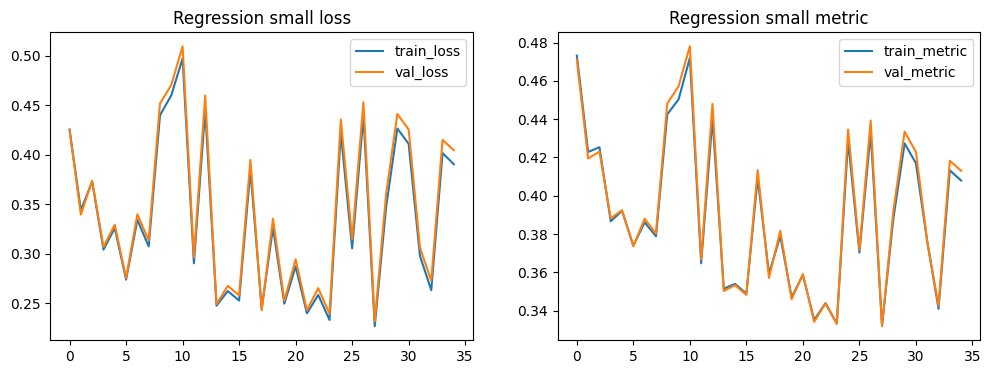

Training regression model: medium
Epoch 001 | lr=0.000333 | train_loss=0.3519 | val_loss=0.3435 | train_mae=0.4300 | val_mae=0.4254
Epoch 002 | lr=0.000667 | train_loss=0.3352 | val_loss=0.3332 | train_mae=0.4065 | val_mae=0.4034
Epoch 003 | lr=0.001000 | train_loss=0.3066 | val_loss=0.2964 | train_mae=0.3865 | val_mae=0.3826
Epoch 004 | lr=0.001000 | train_loss=0.3051 | val_loss=0.2952 | train_mae=0.3914 | val_mae=0.3876
Epoch 005 | lr=0.001000 | train_loss=0.3307 | val_loss=0.3176 | train_mae=0.3982 | val_mae=0.3951
Epoch 006 | lr=0.001000 | train_loss=0.3291 | val_loss=0.2986 | train_mae=0.3776 | val_mae=0.3767


/tmp/ipykernel_239585/642668115.py:8: RuntimeWarning: overflow encountered in exp
  self.output = np.where(input > 0, input, self.alpha * (np.exp(input) - 1))


Epoch 007 | lr=0.001000 | train_loss=0.3277 | val_loss=0.3009 | train_mae=0.3754 | val_mae=0.3752
Epoch 008 | lr=0.001000 | train_loss=0.3204 | val_loss=0.3084 | train_mae=0.3843 | val_mae=0.3846
Epoch 009 | lr=0.001000 | train_loss=0.3453 | val_loss=0.3431 | train_mae=0.4086 | val_mae=0.4095
Epoch 010 | lr=0.001000 | train_loss=0.4298 | val_loss=0.4378 | train_mae=0.4667 | val_mae=0.4671
Epoch 011 | lr=0.001000 | train_loss=0.3932 | val_loss=0.3970 | train_mae=0.4477 | val_mae=0.4473
Epoch 012 | lr=0.000500 | train_loss=0.3152 | val_loss=0.2912 | train_mae=0.3684 | val_mae=0.3681
Epoch 013 | lr=0.000500 | train_loss=0.3255 | val_loss=0.2948 | train_mae=0.3588 | val_mae=0.3602
Epoch 014 | lr=0.000500 | train_loss=0.3077 | val_loss=0.2986 | train_mae=0.3762 | val_mae=0.3763
Epoch 015 | lr=0.000500 | train_loss=0.3371 | val_loss=0.3292 | train_mae=0.3942 | val_mae=0.3948
Epoch 016 | lr=0.000500 | train_loss=0.4376 | val_loss=0.4452 | train_mae=0.4666 | val_mae=0.4680
Epoch 017 | lr=0.000

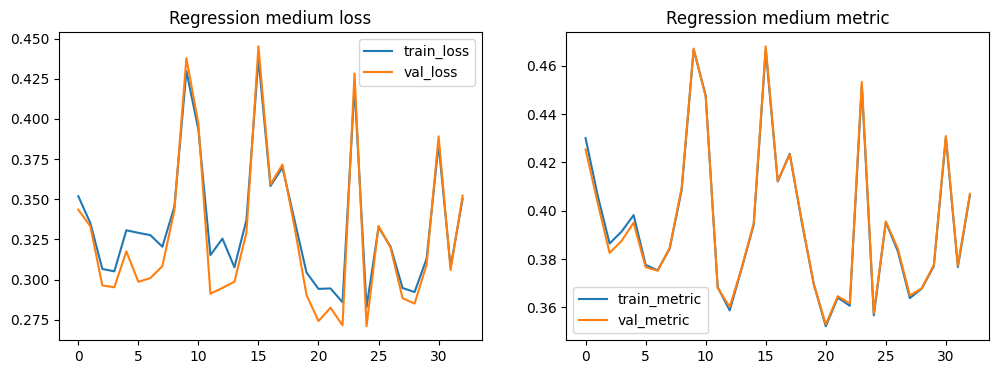

Training regression model: large
Epoch 001 | lr=0.000333 | train_loss=0.3771 | val_loss=0.3778 | train_mae=0.4524 | val_mae=0.4493
Epoch 002 | lr=0.000667 | train_loss=0.3205 | val_loss=0.3186 | train_mae=0.3971 | val_mae=0.3937
Epoch 003 | lr=0.001000 | train_loss=0.2957 | val_loss=0.2958 | train_mae=0.3744 | val_mae=0.3737
Epoch 004 | lr=0.001000 | train_loss=0.2557 | val_loss=0.2528 | train_mae=0.3582 | val_mae=0.3561
Epoch 005 | lr=0.001000 | train_loss=0.4307 | val_loss=0.4430 | train_mae=0.4453 | val_mae=0.4508
Epoch 006 | lr=0.001000 | train_loss=0.2478 | val_loss=0.2501 | train_mae=0.3504 | val_mae=0.3503
Epoch 007 | lr=0.001000 | train_loss=0.3526 | val_loss=0.3581 | train_mae=0.3957 | val_mae=0.3978
Epoch 008 | lr=0.001000 | train_loss=0.4290 | val_loss=0.4423 | train_mae=0.4397 | val_mae=0.4452
Epoch 009 | lr=0.001000 | train_loss=0.2424 | val_loss=0.2431 | train_mae=0.3360 | val_mae=0.3358
Epoch 010 | lr=0.001000 | train_loss=0.2600 | val_loss=0.2677 | train_mae=0.3432 | va

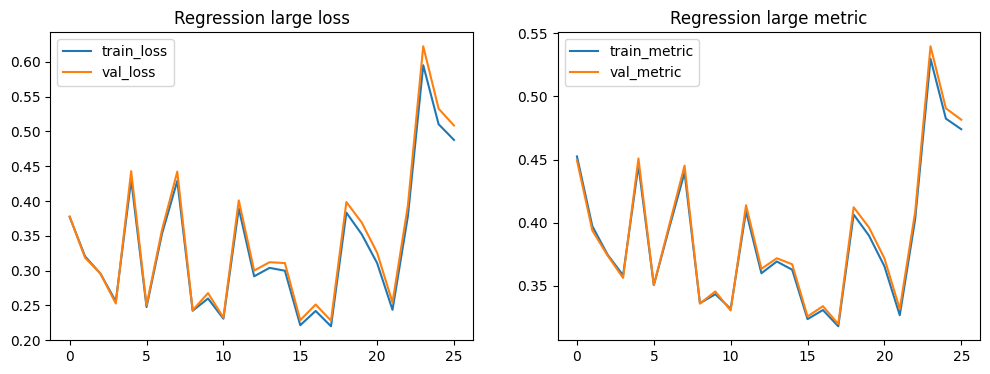

In [28]:
regression_configs = {
    "small": {"hidden_dims": (64, 32), "activation": "relu", "dropout_p": 0.10},
    "medium": {"hidden_dims": (128, 64, 32), "activation": "elu", "dropout_p": 0.15},
    "large": {"hidden_dims": (256, 128, 64, 32), "activation": "gelu", "dropout_p": 0.20},
}

regression_results = {}

for name, cfg in regression_configs.items():
    print("=" * 80)
    print(f"Training regression model: {name}")

    model = build_regression_model(
        input_dim=X_train.shape[1],
        hidden_dims=cfg["hidden_dims"],
        activation=cfg["activation"],
        dropout_p=cfg["dropout_p"],
    )

    optimizer = Adam(model, lr=1e-3, weight_decay=1e-4)
    scheduler = WarmupThenStepScheduler(
        optimizer, base_lr=1e-3, warmup_epochs=3, step_size=8, gamma=0.5
    )
    early_stopping = EarlyStopping(patience=8, mode="min")
    criterion = MSECriterion()

    best_path = f"best_regression_{name}.pkl"

    history = train_regression_model(
        model,
        optimizer,
        criterion,
        X_train,
        y_train,
        X_val,
        y_val,
        epochs=35,
        batch_size=128,
        scheduler=scheduler,
        early_stopping=early_stopping,
        best_model_path=best_path,
    )

    model.evaluate()
    test_pred = model.forward(X_test)
    test_loss = criterion.forward(test_pred, y_test)
    test_mae = mae_metric(test_pred, y_test)

    regression_results[name] = {
        "model": model,
        "history": history,
        "test_loss": test_loss,
        "test_mae": test_mae,
        "path": best_path,
    }

    print(f"[{name}] test_loss={test_loss:.4f}, test_mae={test_mae:.4f}")
    plot_history(history, title_prefix=f"Regression {name}")

## 2. Мультиклассификация на MNIST

Здесь выполняется требование:
- свёртки;
- maxpool;
- flatten;
- log-softmax / NLL.

Для лосса используем `ClassNLLCriterion`, для метрики `accuracy`.

In [29]:
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

X_train_full = train_dataset.data.numpy().astype(np.float32) / 255.0
y_train_full = train_dataset.targets.numpy().astype(np.int64)

X_test_full = test_dataset.data.numpy().astype(np.float32) / 255.0
y_test_full = test_dataset.targets.numpy().astype(np.int64)

# уменьшаем выборки
train_subset_size = 100
test_subset_size = 100

train_idx = np.random.choice(len(X_train_full), train_subset_size, replace=False)
test_idx = np.random.choice(len(X_test_full), test_subset_size, replace=False)

X_train_mnist = X_train_full[train_idx]
y_train_mnist = y_train_full[train_idx]

X_test_mnist = X_test_full[test_idx]
y_test_mnist = y_test_full[test_idx]

# добавляем channel dimension
X_train_mnist = X_train_mnist[:, None, :, :]
X_test_mnist = X_test_mnist[:, None, :, :]

# делим train на train/val
X_train_mnist, X_val_mnist, y_train_mnist, y_val_mnist = train_test_split(
    X_train_mnist,
    y_train_mnist,
    test_size=0.1,
    random_state=42,
    stratify=y_train_mnist
)

Y_train_mnist_oh = to_one_hot(y_train_mnist, 10)
Y_val_mnist_oh = to_one_hot(y_val_mnist, 10)
Y_test_mnist_oh = to_one_hot(y_test_mnist, 10)

print(X_train_mnist.shape, X_val_mnist.shape, X_test_mnist.shape)

(90, 1, 28, 28) (10, 1, 28, 28) (100, 1, 28, 28)


In [30]:
def build_mnist_cnn(dropout_p=0.2):
    model = Sequential()

    model.add(Conv2d(1, 16, kernel_size=3, stride=1, padding=1, bias=True))
    model.add(ReLU())
    model.add(MaxPool2d(kernel_size=2, stride=2, padding=0))

    model.add(Conv2d(16, 32, kernel_size=3, stride=1, padding=1, bias=True))
    model.add(ReLU())
    model.add(MaxPool2d(kernel_size=2, stride=2, padding=0))

    model.add(Flatten())
    model.add(Linear(32 * 7 * 7, 128))
    model.add(BatchNormalization(alpha=0.9))
    model.add(ChannelwiseScaling(128))
    model.add(ReLU())
    model.add(Dropout(p=dropout_p))
    model.add(Linear(128, 10))
    model.add(LogSoftMax())

    return model

In [31]:
def train_classification_model(
    model,
    optimizer,
    criterion,
    X_train,
    y_train_oh,
    y_train_labels,
    X_val,
    y_val_oh,
    y_val_labels,
    epochs=12,
    batch_size=128,
    scheduler=None,
    early_stopping=None,
    best_model_path="best_mnist.pkl",
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_metric": [],
        "val_metric": [],
        "lr": [],
    }

    best_saved = False

    for epoch in range(epochs):
        model.train()
        lr = scheduler.step(epoch) if scheduler is not None else optimizer.lr
        history["lr"].append(lr)

        for xb, yb in iterate_minibatches(X_train, y_train_oh, batch_size=batch_size, shuffle=True):
            optimizer.zero_grad()
            log_probs = model.forward(xb)
            loss = criterion.forward(log_probs, yb)
            grad = criterion.backward(log_probs, yb)
            model.backward(xb, grad)
            optimizer.step()

        model.evaluate()

        train_log_probs = model.forward(X_train)
        val_log_probs = model.forward(X_val)

        train_loss = criterion.forward(train_log_probs, y_train_oh)
        val_loss = criterion.forward(val_log_probs, y_val_oh)

        train_acc = accuracy_from_logits(train_log_probs, y_train_labels)
        val_acc = accuracy_from_logits(val_log_probs, y_val_labels)

        history["train_loss"].append(float(train_loss))
        history["val_loss"].append(float(val_loss))
        history["train_metric"].append(float(train_acc))
        history["val_metric"].append(float(val_acc))

        improved = True
        stop = False
        if early_stopping is not None:
            improved, stop = early_stopping.step(-val_acc)

        if improved:
            save_model_params(model, best_model_path)
            best_saved = True

        print(
            f"Epoch {epoch+1:03d} | lr={lr:.6f} | "
            f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
            f"train_acc={train_acc:.4f} | val_acc={val_acc:.4f}"
        )

        if stop:
            print("Early stopping triggered.")
            break

    if best_saved:
        load_model_params(model, best_model_path)

    return history

Epoch 001 | lr=0.000500 | train_loss=2.2920 | val_loss=2.2922 | train_acc=0.1444 | val_acc=0.1000
Epoch 002 | lr=0.001000 | train_loss=2.2654 | val_loss=2.2728 | train_acc=0.1667 | val_acc=0.2000
Epoch 003 | lr=0.001000 | train_loss=2.2381 | val_loss=2.2538 | train_acc=0.2333 | val_acc=0.2000
Epoch 004 | lr=0.001000 | train_loss=2.2092 | val_loss=2.2327 | train_acc=0.4667 | val_acc=0.3000
Epoch 005 | lr=0.001000 | train_loss=2.1797 | val_loss=2.2117 | train_acc=0.5778 | val_acc=0.4000
Epoch 006 | lr=0.001000 | train_loss=2.1503 | val_loss=2.1915 | train_acc=0.7000 | val_acc=0.5000
Epoch 007 | lr=0.000500 | train_loss=2.1302 | val_loss=2.1775 | train_acc=0.7222 | val_acc=0.5000
Epoch 008 | lr=0.000500 | train_loss=2.1091 | val_loss=2.1629 | train_acc=0.7556 | val_acc=0.5000
Epoch 009 | lr=0.000500 | train_loss=2.0870 | val_loss=2.1477 | train_acc=0.7778 | val_acc=0.7000
Epoch 010 | lr=0.000500 | train_loss=2.0637 | val_loss=2.1315 | train_acc=0.8111 | val_acc=0.7000
Epoch 011 | lr=0.000

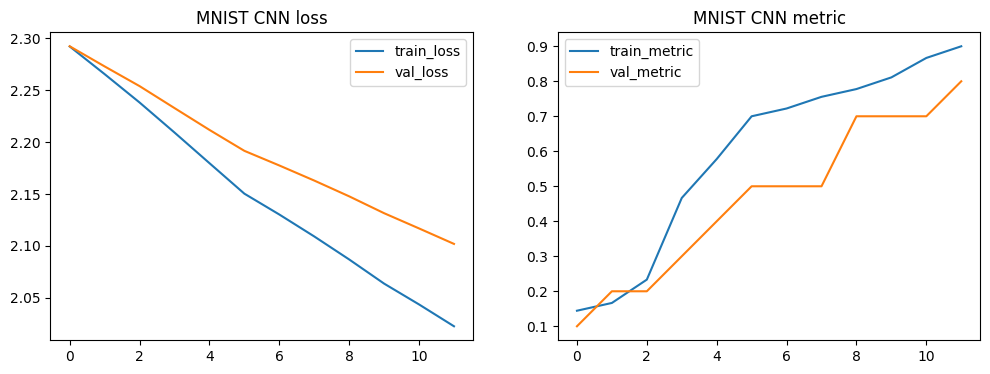

In [32]:
mnist_model = build_mnist_cnn(dropout_p=0.2)
mnist_optimizer = Adam(mnist_model, lr=1e-3, weight_decay=1e-4)
mnist_scheduler = WarmupThenStepScheduler(
    mnist_optimizer, base_lr=1e-3, warmup_epochs=2, step_size=4, gamma=0.5
)
mnist_early_stopping = EarlyStopping(patience=4, mode="min")
mnist_criterion = ClassNLLCriterion()

mnist_history = train_classification_model(
    mnist_model,
    mnist_optimizer,
    mnist_criterion,
    X_train_mnist,
    Y_train_mnist_oh,
    y_train_mnist,
    X_val_mnist,
    Y_val_mnist_oh,
    y_val_mnist,
    epochs=12,
    batch_size=128,
    scheduler=mnist_scheduler,
    early_stopping=mnist_early_stopping,
    best_model_path="best_mnist.pkl",
)

plot_history(mnist_history, title_prefix="MNIST CNN")

In [33]:
mnist_model.evaluate()
test_log_probs = mnist_model.forward(X_test_mnist)
test_loss = mnist_criterion.forward(test_log_probs, Y_test_mnist_oh)
test_acc = accuracy_from_logits(test_log_probs, y_test_mnist)

print(f"MNIST test_loss={test_loss:.4f}")
print(f"MNIST test_acc={test_acc:.4f}")

MNIST test_loss=2.0953
MNIST test_acc=0.7100


## 3. Автоэнкодер

Здесь берём тоже `MNIST`, потому что:
- данные уже загружены;
- удобно визуализировать реконструкции;
- можно сделать encoder на свёртках + FC;
- decoder на FC.

Для лосса используем `MSECriterion`.

In [34]:
class Sigmoid(Module):
    def updateOutput(self, input):
        self.output = 1.0 / (1.0 + np.exp(-input))
        return self.output

    def updateGradInput(self, input, gradOutput):
        sig = self.output
        self.gradInput = gradOutput * sig * (1.0 - sig)
        return self.gradInput

    def __repr__(self):
        return "Sigmoid"

In [35]:
class ConvFCEncoder(Module):
    def __init__(self, latent_dim=32, dropout_p=0.2):
        super(ConvFCEncoder, self).__init__()
        self.features = Sequential()
        self.features.add(Conv2d(1, 8, kernel_size=3, stride=1, padding=1))
        self.features.add(ReLU())
        self.features.add(MaxPool2d(2, 2, 0))
        self.features.add(Conv2d(8, 16, kernel_size=3, stride=1, padding=1))
        self.features.add(ReLU())
        self.features.add(MaxPool2d(2, 2, 0))
        self.features.add(Flatten())
        self.features.add(Linear(16 * 7 * 7, 128))
        self.features.add(BatchNormalization(alpha=0.9))
        self.features.add(ChannelwiseScaling(128))
        self.features.add(ReLU())
        self.features.add(Dropout(dropout_p))
        self.features.add(Linear(128, latent_dim))

    def updateOutput(self, input):
        self.output = self.features.forward(input)
        return self.output

    def backward(self, input, gradOutput):
        self.gradInput = self.features.backward(input, gradOutput)
        return self.gradInput

    def zeroGradParameters(self):
        self.features.zeroGradParameters()

    def getParameters(self):
        return self.features.getParameters()

    def getGradParameters(self):
        return self.features.getGradParameters()

    def train(self):
        self.training = True
        self.features.train()

    def evaluate(self):
        self.training = False
        self.features.evaluate()

    def __repr__(self):
        return "ConvFCEncoder"


class FCDecoder(Module):
    def __init__(self, latent_dim=32, dropout_p=0.2):
        super(FCDecoder, self).__init__()
        self.net = Sequential()
        self.net.add(Linear(latent_dim, 128))
        self.net.add(BatchNormalization(alpha=0.9))
        self.net.add(ChannelwiseScaling(128))
        self.net.add(ReLU())
        self.net.add(Dropout(dropout_p))
        self.net.add(Linear(128, 28 * 28))
        self.net.add(Sigmoid())

    def updateOutput(self, input):
        out = self.net.forward(input)
        self.output = out.reshape(-1, 1, 28, 28)
        return self.output

    def backward(self, input, gradOutput):
        grad_flat = gradOutput.reshape(gradOutput.shape[0], -1)
        self.gradInput = self.net.backward(input, grad_flat)
        return self.gradInput

    def zeroGradParameters(self):
        self.net.zeroGradParameters()

    def getParameters(self):
        return self.net.getParameters()

    def getGradParameters(self):
        return self.net.getGradParameters()

    def train(self):
        self.training = True
        self.net.train()

    def evaluate(self):
        self.training = False
        self.net.evaluate()

    def __repr__(self):
        return "FCDecoder"


class AutoEncoder(Module):
    def __init__(self, latent_dim=32, dropout_p=0.2):
        super(AutoEncoder, self).__init__()
        self.encoder = ConvFCEncoder(latent_dim=latent_dim, dropout_p=dropout_p)
        self.decoder = FCDecoder(latent_dim=latent_dim, dropout_p=dropout_p)

    def updateOutput(self, input):
        self.latent = self.encoder.forward(input)
        self.output = self.decoder.forward(self.latent)
        return self.output

    def backward(self, input, gradOutput):
        grad_latent = self.decoder.backward(self.latent, gradOutput)
        self.gradInput = self.encoder.backward(input, grad_latent)
        return self.gradInput

    def zeroGradParameters(self):
        self.encoder.zeroGradParameters()
        self.decoder.zeroGradParameters()

    def getParameters(self):
        return [self.encoder.getParameters(), self.decoder.getParameters()]

    def getGradParameters(self):
        return [self.encoder.getGradParameters(), self.decoder.getGradParameters()]

    def train(self):
        self.training = True
        self.encoder.train()
        self.decoder.train()

    def evaluate(self):
        self.training = False
        self.encoder.evaluate()
        self.decoder.evaluate()

    def __repr__(self):
        return "AutoEncoder"

In [36]:
def train_autoencoder(
    model,
    optimizer,
    criterion,
    X_train,
    X_val,
    epochs=15,
    batch_size=128,
    scheduler=None,
    early_stopping=None,
    best_model_path="best_autoencoder.pkl",
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "lr": [],
    }

    best_saved = False

    for epoch in range(epochs):
        model.train()
        lr = scheduler.step(epoch) if scheduler is not None else optimizer.lr
        history["lr"].append(lr)

        batch_losses = []

        for xb in iterate_minibatches(X_train, y=None, batch_size=batch_size, shuffle=True):
            optimizer.zero_grad()
            recon = model.forward(xb)
            loss = criterion.forward(recon, xb)
            grad = criterion.backward(recon, xb)
            model.backward(xb, grad)
            optimizer.step()
            batch_losses.append(loss)

        model.evaluate()
        train_recon = model.forward(X_train[:2048])
        val_recon = model.forward(X_val[:2048])

        train_loss = criterion.forward(train_recon, X_train[:2048])
        val_loss = criterion.forward(val_recon, X_val[:2048])

        history["train_loss"].append(float(train_loss))
        history["val_loss"].append(float(val_loss))

        improved = True
        stop = False
        if early_stopping is not None:
            improved, stop = early_stopping.step(val_loss)

        if improved:
            save_model_params(model, best_model_path)
            best_saved = True

        print(
            f"Epoch {epoch+1:03d} | lr={lr:.6f} | "
            f"train_loss={train_loss:.6f} | val_loss={val_loss:.6f}"
        )

        if stop:
            print("Early stopping triggered.")
            break

    if best_saved:
        load_model_params(model, best_model_path)

    return history

Epoch 001 | lr=0.000500 | train_loss=180.822506 | val_loss=180.581461
Epoch 002 | lr=0.001000 | train_loss=179.983002 | val_loss=179.739820
Epoch 003 | lr=0.001000 | train_loss=179.181207 | val_loss=178.935431
Epoch 004 | lr=0.001000 | train_loss=178.341187 | val_loss=178.098478
Epoch 005 | lr=0.001000 | train_loss=177.378676 | val_loss=177.134444
Epoch 006 | lr=0.001000 | train_loss=176.250179 | val_loss=176.009606
Epoch 007 | lr=0.001000 | train_loss=174.981568 | val_loss=174.747780
Epoch 008 | lr=0.000500 | train_loss=174.022955 | val_loss=173.793588
Epoch 009 | lr=0.000500 | train_loss=172.936812 | val_loss=172.718250
Epoch 010 | lr=0.000500 | train_loss=171.696855 | val_loss=171.490845
Epoch 011 | lr=0.000500 | train_loss=170.328243 | val_loss=170.136517
Epoch 012 | lr=0.000500 | train_loss=168.886969 | val_loss=168.714782
Epoch 013 | lr=0.000250 | train_loss=167.645959 | val_loss=167.487256
Epoch 014 | lr=0.000250 | train_loss=166.383425 | val_loss=166.238433
Epoch 015 | lr=0.000

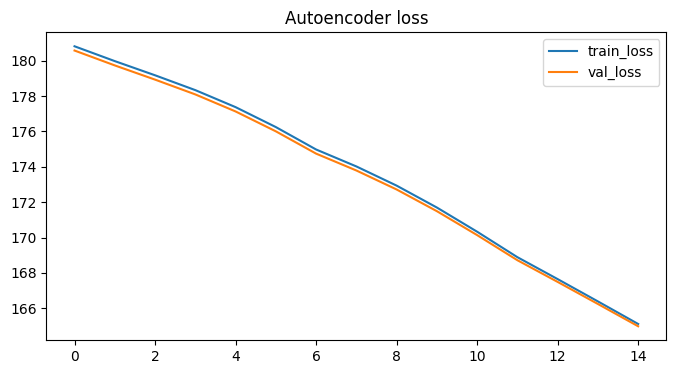

In [37]:
autoencoder = AutoEncoder(latent_dim=32, dropout_p=0.2)
ae_optimizer = Adam(autoencoder, lr=1e-3, weight_decay=1e-5)
ae_scheduler = WarmupThenStepScheduler(
    ae_optimizer, base_lr=1e-3, warmup_epochs=2, step_size=5, gamma=0.5
)
ae_early_stopping = EarlyStopping(patience=4, mode="min")
ae_criterion = MSECriterion()

ae_history = train_autoencoder(
    autoencoder,
    ae_optimizer,
    ae_criterion,
    X_train_mnist,
    X_val_mnist,
    epochs=15,
    batch_size=128,
    scheduler=ae_scheduler,
    early_stopping=ae_early_stopping,
    best_model_path="best_autoencoder.pkl",
)

plt.figure(figsize=(8, 4))
plt.plot(ae_history["train_loss"], label="train_loss")
plt.plot(ae_history["val_loss"], label="val_loss")
plt.title("Autoencoder loss")
plt.legend()
plt.show()

In [38]:
autoencoder.evaluate()
ae_test_recon = autoencoder.forward(X_test_mnist[:2048])
ae_test_loss = ae_criterion.forward(ae_test_recon, X_test_mnist[:2048])
print(f"Autoencoder test_loss={ae_test_loss:.6f}")

Autoencoder test_loss=165.492475


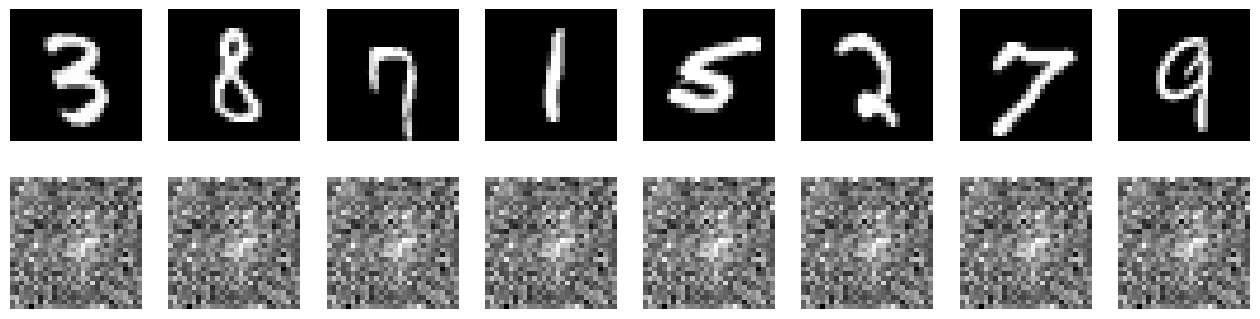

In [39]:
def show_reconstructions(model, X, n=8):
    model.evaluate()
    recon = model.forward(X[:n])

    plt.figure(figsize=(2*n, 4))
    for i in range(n):
        plt.subplot(2, n, i + 1)
        plt.imshow(X[i, 0], cmap="gray")
        plt.axis("off")
        if i == 0:
            plt.ylabel("orig")

        plt.subplot(2, n, n + i + 1)
        plt.imshow(recon[i, 0], cmap="gray")
        plt.axis("off")
        if i == 0:
            plt.ylabel("recon")
    plt.show()

show_reconstructions(autoencoder, X_test_mnist, n=8)